## Imports

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("/home/pratush/Downloads/Fin_HDI.csv")
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


/tmp/ipykernel_101796/1413076087.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/home/pratush/Downloads/Fin_HDI.csv")
/tmp/ipykernel_101796/1413076087.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


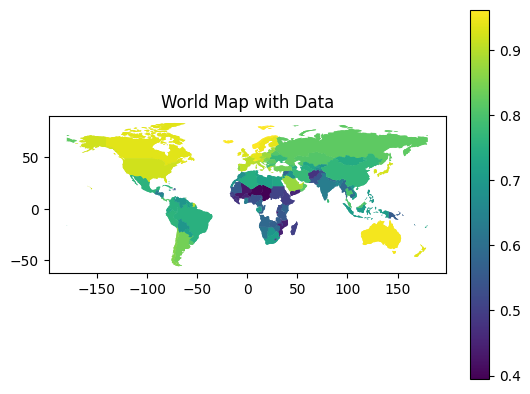

In [3]:
world_data = world.merge(data, left_on='name', right_on='Country')


world_data.plot(column='Value', legend=True)
plt.title('World Map with Data')

plt.show()


## Select Country

In [5]:
russia_row = world_data[world_data['Country'] == 'Russia']

## Save selected countries coords as JSON

In [8]:
import geopandas as gpd

# Assuming 'russia_row' is the GeoDataFrame containing the Multipolygon for Russia
russia_multipolygon = russia_row.geometry.iloc[0]  # Assuming there's only one row for Russia

# Extracting the longitude and latitude values
lon_lat_arrays = {
    'longitude': [],
    'latitude': []
}

# Extracting coordinates from the Multipolygon
for geom in russia_multipolygon.geoms:
    if geom.exterior is not None:
        lon_lat_arrays['longitude'].extend(list(geom.exterior.xy[0]))
        lon_lat_arrays['latitude'].extend(list(geom.exterior.xy[1]))

# Saving longitude and latitude as separate arrays in a JSON file
import json

with open('russia_lon_lat_arraysV2.json', 'w') as file:
    json.dump(lon_lat_arrays, file)
